# Build and analyze an SAE feature dataset

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rotskoff-group/idiom/blob/main/cookbook/notebooks/sae_features.ipynb)

Download the held-out validation split from `jxliu2/idiom-db`, build a reusable feature
dataset for its IDRs, rank features, and inspect their strongest sequences and residue-level
activation traces. The SAE loads its recorded host model and layer automatically.

A GPU is recommended. In Colab, select **Runtime → Change runtime type → GPU** before running.
`DEVICE = "auto"` falls back to CPU.

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("idiom") is None:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "git+https://github.com/rotskoff-group/idiom.git",
    ])

from huggingface_hub import hf_hub_download
import idiom

print("IDiom loaded from", idiom.__file__)

/data2/scratch/jxliu2/idiom-public/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


IDiom loaded from /data2/scratch/jxliu2/idiom-public/src/idiom/__init__.py


In [2]:
from pathlib import Path

SAE = "jxliu2/idiomsae-300M-L18-k32" # Hub ID or local release directory
DEVICE = "auto"
INPUT_FASTA = None # None downloads the held-out validation split; or set a local record FASTA
MAX_RECORDS = 10_000 # Inspect the first 10,000 records; None uses the full input
OUT_DIR = Path("sae_feature_dataset") # Build overwrites dataset files in this directory
BATCH_SIZE = 32 # Lower this if GPU memory is limited
N_TOP = 10
N_FEATURES = 3 # Number of ranked features when FEATURE_IDS is None
FEATURE_IDS = [6151, 10538, 4178, 1752] # Curated examples for the released SAE; None uses rankings
N_EXAMPLES = 3 # Top-activating sequences per feature
FEATURE_ID = None # Set an ID to inspect just that feature

## 1. Prepare a record FASTA

Each header ends in `_IDR_x-y`, with **1-based inclusive** coordinates in the full protein:

```text
>protein_A_IDR_3-9
MEDSKVDNRPQACDEFG
```

For isolated IDRs, use `_IDR_1-<sequence_length>`. The reader converts spans to 0-based,
half-open coordinates and skips malformed records and non-canonical sequences.
By default, this notebook downloads `idiom-db/idiom-db-v1_validation.fasta` from
`jxliu2/idiom-db` and analyzes the first 10,000 valid records with a batch size of 32.
Set `INPUT_FASTA` to use your own data or `MAX_RECORDS=None` to analyze the full input.
Lower `MAX_RECORDS` for a quicker run and `BATCH_SIZE` if GPU memory is limited.

In [ ]:
from itertools import islice

from idiom.data.io import read_records

fasta = Path(INPUT_FASTA) if INPUT_FASTA is not None else Path(hf_hub_download(
    "jxliu2/idiom-db", "idiom-db/idiom-db-v1_validation.fasta", repo_type="dataset",
))
records = list(islice(read_records(fasta), MAX_RECORDS))
if not records:
    raise ValueError("No valid records found; check the FASTA headers and sequences.")

print(f"Loaded {len(records)} records from {fasta}")
for record in records[:3]:
    idr = record.full_seq[record.idr_start:record.idr_end]
    print(f"{record.accession}: {len(record.full_seq)} residues, IDR length {len(idr)}")

## 2. Build the feature dataset

The released SAE uses **unprompted IDRs** (`region="idr"`, `fim_mode="unprompted"`), so protein
flanks are excluded. A different SAE supplies its own layer, region, and prompt format.

The builder saves top-k feature IDs and values for each selected residue, sequence indices,
FIM-string positions, the strings themselves, and dataset metadata. Building holds the selected
records and output arrays in memory. Full validation analysis can require substantial host RAM
and runtime; reduce `MAX_RECORDS` to limit total memory and `BATCH_SIZE` to limit GPU memory.

In [4]:
from idiom import IDiomSAE

sae = IDiomSAE.from_pretrained(SAE, device=DEVICE)
print(f"Host: {sae.host_model}; layer: {sae.layer}")
print(f"Region: {sae.region}; FIM mode: {sae.fim_mode}; latents: {sae.sae.num_latents}")

lengths = [
    r.idr_end - r.idr_start if sae.fim_mode == "unprompted" else len(r.full_seq)
    for r in records
]
if max(lengths) + 4 > sae.model.cfg.max_seq_len:
    raise ValueError("An input exceeds the host model's context length, including START and FIM markers.")

sae.build_feature_dataset(records, OUT_DIR, batch_size=BATCH_SIZE)
print(f"Saved feature dataset to {OUT_DIR.resolve()}")

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 258.39it/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 64776.90it/s]

Host: jxliu2/idiom-300M; layer: 18
Region: idr; FIM mode: unprompted; latents: 16384


Saved feature dataset to /data2/scratch/jxliu2/idiom-public/runs/notebook-execution/20260907-143744/sae_feature_dataset


## 3. Browse features

Open the saved dataset without rerunning the models. Arrays are memory-mapped by default.
`feature_ranking()` returns three arrays indexed by **feature ID**: maximum activation,
total activation, and the number of residue rows with positive activation.
These are descriptive rankings, not statistical enrichment tests.

In [5]:
import matplotlib.pyplot as plt
import numpy as np

from idiom.sae.features import FeatureDataset

# This section can also inspect a previously built OUT_DIR
dataset = FeatureDataset(OUT_DIR)
maximum, total, count = dataset.feature_ranking()
active = np.flatnonzero(count > 0)
ranked = active[np.argsort(-maximum[active], kind="stable")]
print(f"{dataset.n_seqs} sequences, {dataset.top_indices.shape[0]} residue rows")
print(f"{len(active)} of {dataset.num_latents} features have positive activations")
print(f"{'feature':>8} {'maximum':>10} {'total':>12} {'firing rows':>12}")
for feature in ranked[:N_TOP]:
    print(f"{feature:8d} {maximum[feature]:10.3f} {total[feature]:12.3f} {count[feature]:12d}")

10000 sequences, 903716 residue rows
16382 of 16384 features have positive activations
 feature    maximum        total  firing rows
    1462   1166.965     8017.867          173
   15401   1113.421   857202.500         9105
    2975   1068.265     9337.780          198
    7466    999.080     5249.875          132
   12164    952.024     4972.919          105
   15634    920.246     7201.964          163
   13590    869.899     7492.260          216
   12830    850.008    10780.339          235
     270    798.694     4853.778           32
     789    787.460     5096.309           61


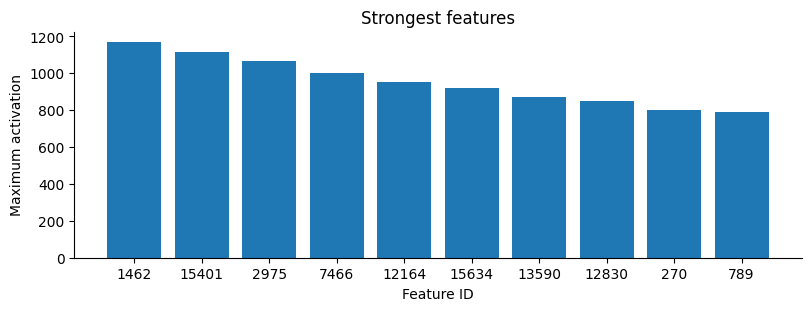

In [6]:
top = ranked[:N_TOP]
if len(top):
    fig, ax = plt.subplots(figsize=(8, 3), constrained_layout=True)
    ax.bar(np.arange(len(top)), maximum[top])
    ax.set_xticks(np.arange(len(top)), labels=top)
    ax.set(xlabel="Feature ID", ylabel="Maximum activation", title="Strongest features")
    ax.spines[["top", "right"]].set_visible(False)
    plt.show()
else:
    print("No features fired on this dataset.")

For an interactive browser in a **local repository clone**, run this optional command in a
terminal (replace the dataset path with the absolute `OUT_DIR` printed above):

```bash
streamlit run src/idiom/sae/features/feature_viewer.py -- --features /path/to/sae_feature_dataset
```

The viewer ranks by maximum activation, total activation, or firing count and shades residues
in the strongest sequences. The inline analysis below works in both Colab and local notebooks.

## 4. Recognizable IDR sequence patterns

These examples were selected by inspecting activations in the 10,000-record validation sample
using `jxliu2/idiomsae-300M-L18-k32`. They illustrate familiar sequence patterns rather than
simply the largest activations. The biological connections below describe those patterns;
they are not validated functional annotations of the features or of every displayed protein.

| Feature | Pattern in activating windows | Biological connection |
|---|---|---|
| 6151 | Poly-proline / proline-rich tracts | Proline-rich motifs can mediate SH3 interactions ([Li et al., 2012](https://pubmed.ncbi.nlm.nih.gov/22398450/)). |
| 10538 | Arginine–serine (RS) repeats | RS domains participate in pre-mRNA splicing ([Shen et al., 2004](https://pubmed.ncbi.nlm.nih.gov/14967144/)). |
| 4178 | Arginine–glycine / RGG-rich tracts | RGG motifs can recognize RNA ([Vasilyev et al., 2015](https://pubmed.ncbi.nlm.nih.gov/26374839/)). |
| 1752 | FG-rich repeats, including DIFG-like patterns | FG-repeat domains underlie nuclear-pore selective permeability ([Frey & Görlich, 2007](https://pubmed.ncbi.nlm.nih.gov/17693259/)). |

The gallery shows `N_EXAMPLES` sequences per feature, ranked by peak activation without motif
filtering. Some strong activations can occur outside the named pattern. Edit `FEATURE_IDS` to
choose a set, set it to `None` to show the top `N_FEATURES` by activation, or use `FEATURE_ID`
to inspect one feature. Feature IDs are specific to SAE weights; choose new IDs for another SAE.

Orange shading matches the Streamlit viewer: its intensity is activation divided by that
feature's maximum across the entire dataset, so sequences within a feature share a scale.
Hover over a residue for its activation and position. Sequences use stored FIM order, including
unshaded markers; the firing fraction counts only stored residue rows. Sequence IDs index
`dataset.strings`, not FASTA accessions. The traces below show the first displayed feature.

In [7]:
import html
from IPython.display import HTML, display

if FEATURE_ID is None and FEATURE_IDS is None and not len(ranked):
    raise ValueError("No active features to inspect; try another input dataset.")
if N_FEATURES < 1 or N_EXAMPLES < 1:
    raise ValueError("N_FEATURES and N_EXAMPLES must be positive.")
if FEATURE_ID is not None:
    feature_ids = [int(FEATURE_ID)]
elif FEATURE_IDS is not None:
    feature_ids = FEATURE_IDS
else:
    feature_ids = ranked[:N_FEATURES]
if not len(feature_ids):
    raise ValueError("Choose at least one FEATURE_IDS entry, or use None for ranked features.")
example_labels = {
    6151: "Proline-rich tracts", 10538: "RS repeats",
    4178: "RGG-rich tracts", 1752: "FG-rich repeats",
} if SAE == "jxliu2/idiomsae-300M-L18-k32" else {}

for shown_feature in map(int, feature_ids):
    if not 0 <= shown_feature < dataset.num_latents:
        raise ValueError(f"FEATURE_ID must be between 0 and {dataset.num_latents - 1}.")
    top_ids, scores = dataset.top_sequences(shown_feature, n=N_EXAMPLES, sort_by="peak")
    global_max, peaks, fractions = dataset.feature_stats(shown_feature)
    label = html.escape(example_labels.get(shown_feature, ""))
    title = f"Feature {shown_feature}" + (f" · {label}" if label else "")
    panels = [f"<h4>{title} · dataset maximum {global_max:.3f}</h4>"]
    for rank, (seq_id, score) in enumerate(zip(top_ids, scores), start=1):
        seq_id = int(seq_id)
        sequence = dataset.sequence(seq_id)
        positions, activations = dataset.trace(seq_id, shown_feature)
        full = np.zeros(len(sequence))
        full[positions] = activations
        residues = []
        for position, (residue, activation) in enumerate(zip(sequence, full)):
            alpha = float(activation) / global_max if global_max > 0 else 0.0
            residues.append(
                f'<span title="FIM position {position}; activation {activation:.3f}" '
                f'style="background:rgba(255,140,0,{alpha:.3f})">'
                f'{html.escape(residue)}</span>'
            )
        panels.append(
            f'<div style="margin:12px 0"><strong>#{rank} · sequence {seq_id}</strong>'
            f' · peak={score:.3f} · firing fraction={fractions[seq_id]:.3f}'
            '<div style="font-family:monospace;font-size:13px;word-break:break-all;'
            'line-height:1.6;margin-top:4px">' + "".join(residues) + '</div></div>'
        )
    if not len(top_ids):
        panels.append("<p>This feature has no positive activations; choose another FEATURE_ID.</p>")
    display(HTML("".join(panels)))

feature_id = int(feature_ids[0])
sequence_ids, _ = dataset.top_sequences(feature_id, n=N_EXAMPLES, sort_by="peak")

`trace()` returns positions in the stored **FIM string**, including the `1`, `3`, and `2` markers
but excluding START. These are not original protein coordinates. For the released unprompted
SAE, the string is `132{IDR}` and the first residue is at position 3.

Plots show only stored residue rows. Markers and unselected regions have no activation rows;
an unselected feature at a stored residue has activation zero.

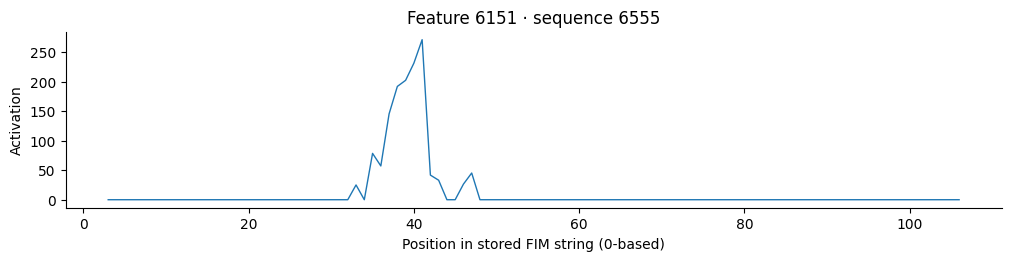

Sequence 6555: peak at FIM position 41 (P)


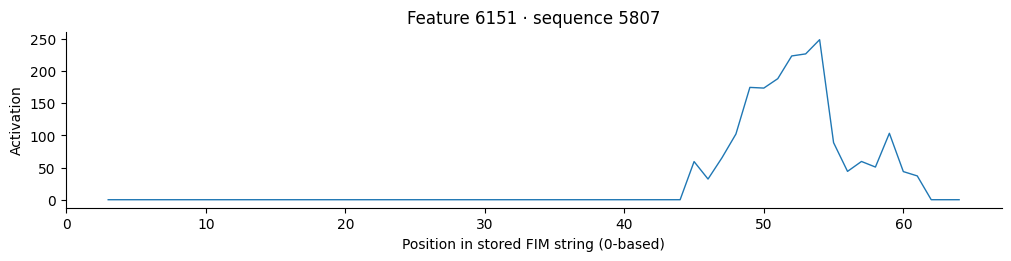

Sequence 5807: peak at FIM position 54 (P)


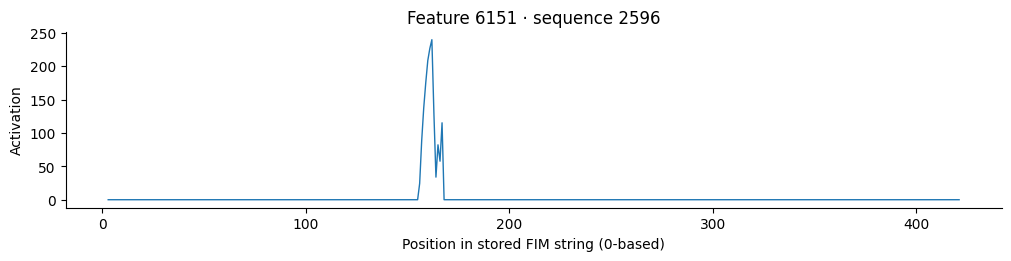

Sequence 2596: peak at FIM position 162 (P)


In [8]:
for seq_id in sequence_ids[:3]:
    seq_id = int(seq_id)
    positions, activations = dataset.trace(seq_id, feature_id)
    fim_string = dataset.sequence(seq_id)

    fig, ax = plt.subplots(figsize=(10, 2.5), constrained_layout=True)
    ax.plot(positions, activations, linewidth=1)
    if len(positions) <= 60:
        ax.set_xticks(positions, labels=[fim_string[int(p)] for p in positions])
        ax.set_xlabel("Residue in FIM order")
    else:
        ax.set_xlabel("Position in stored FIM string (0-based)")
    ax.set_ylabel("Activation")
    ax.set_title(f"Feature {feature_id} · sequence {seq_id}")
    ax.spines[["top", "right"]].set_visible(False)
    plt.show()

    if not len(activations):
        continue
    peak_row = int(activations.argmax())
    peak_pos = int(positions[peak_row])
    print(f"Sequence {seq_id}: peak at FIM position {peak_pos} ({fim_string[peak_pos]})")

## Next: compare against a background

Use [feature_enrichment.ipynb](https://colab.research.google.com/github/rotskoff-group/idiom/blob/main/cookbook/notebooks/feature_enrichment.ipynb)
to find features enriched in a positive sequence set against a background, filter boundary
artifacts, and export a feature signature.